In [4]:
import pandas as pd
import os
from os.path import curdir

xl_path = os.path.join(curdir,'Data','MMA_860_Grocery_Data.csv')
df_xl = pd.read_csv(xl_path, header='infer', index_col='Obs')
def remove_dollar_sign(s):
    return s.replace("$","")
df_xl['Grocery_Bill'] = df_xl['Grocery_Bill'].map(
    remove_dollar_sign)
df_xl['Grocery_Bill'] = df_xl['Grocery_Bill'].astype(
    'float64')
def remove_comma(s):
    return s.replace(",","")
df_xl['Family_Income'] = df_xl['Family_Income'].map(
    remove_dollar_sign).map(remove_comma).astype('int64')
df_xl.head()

,Grocery_Bill,N_Adults,Family_Income,Family_Size,N_Vehicles,Distance_to_Store,Vegetarian,N_Children,Family_Pet
Obs,,,,,,,,,
1,357.73,2,142141,4,3,15,0,2,1
2,276.84,2,145916,2,1,4,0,0,0
3,197.92,1,86185,1,2,14,0,0,0
4,315.75,2,145998,3,1,8,0,1,0
5,202.89,1,79341,1,2,19,1,0,0


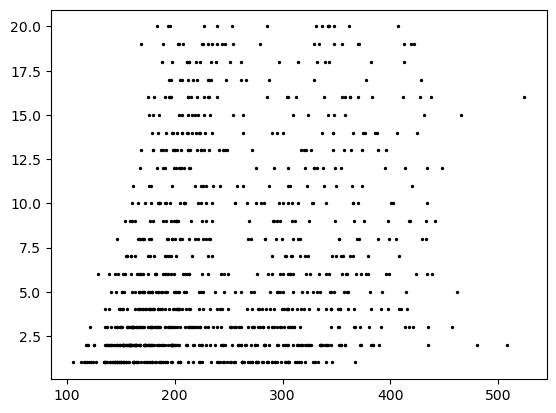

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df_xl['Grocery_Bill'],
    df_xl['Distance_to_Store'],s=2,c='black')

plt.show()

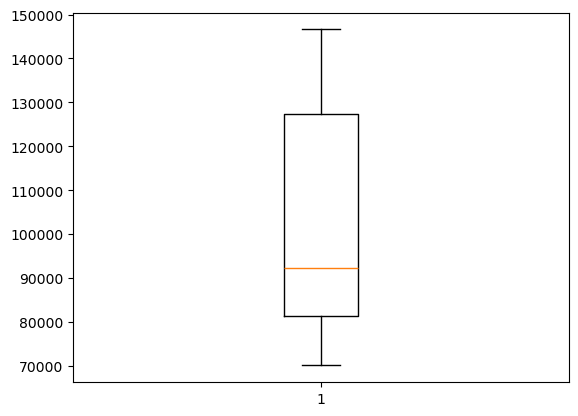

In [6]:
#all of family income
plt.boxplot(df_xl['Family_Income'])

plt.show()

<Axes: title={'center': 'Family_Income'}, xlabel='N_Adults'>

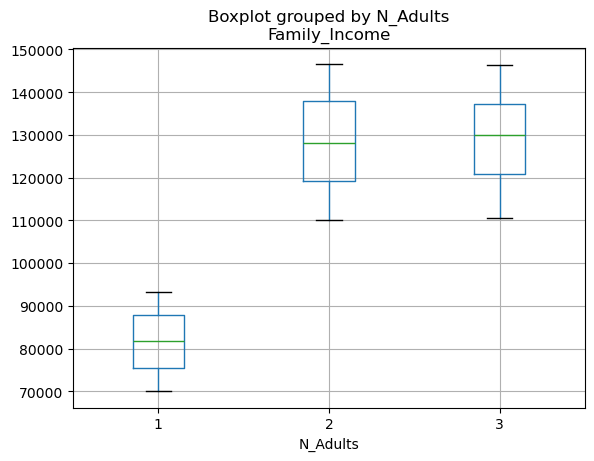

In [7]:
#in pandas, broken out by N_Adults. Very hard to do in matplotlib - sorry!
df_xl.boxplot(by='N_Adults', column='Family_Income')

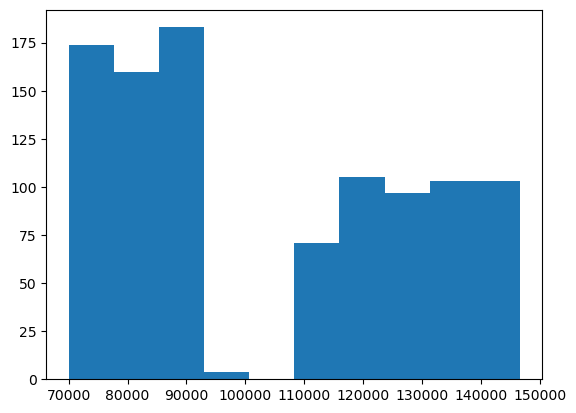

In [8]:
plt.hist(df_xl['Family_Income'])
plt.show()

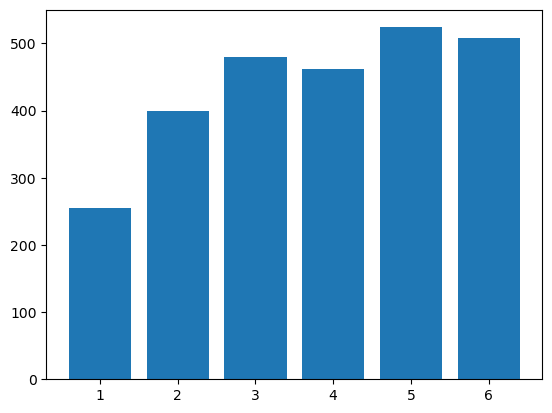

In [9]:
plt.bar(df_xl['Family_Size'], df_xl['Grocery_Bill'])
plt.show()
#this shows the average! 

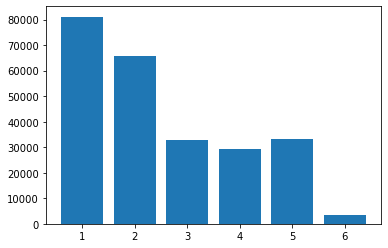

In [44]:
import pandasql

new_df = pandasql.sqldf("SELECT Family_Size, SUM(Grocery_Bill) FROM df_xl GROUP BY Family_Size;")

plt.bar(new_df['Family_Size'], new_df['SUM(Grocery_Bill)'])
plt.show()

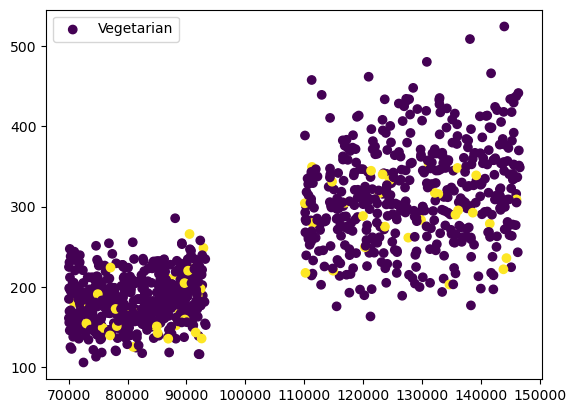

In [10]:
plt.scatter(df_xl['Family_Income'], df_xl['Grocery_Bill'], c=df_xl['Vegetarian'], label='Vegetarian')
plt.legend()
plt.show()
